In [5]:
import seaborn as sns
import pandas as pd

In [6]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [7]:
df =sns.load_dataset('tips')
df.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [9]:
# scatter  

상관관계 시각화 - 분포, 경향성, 이상치 탐색
- 희귀분석, 군집분석 등 탐색적 분석에 활용

<Axes: xlabel='total_bill', ylabel='tip'>

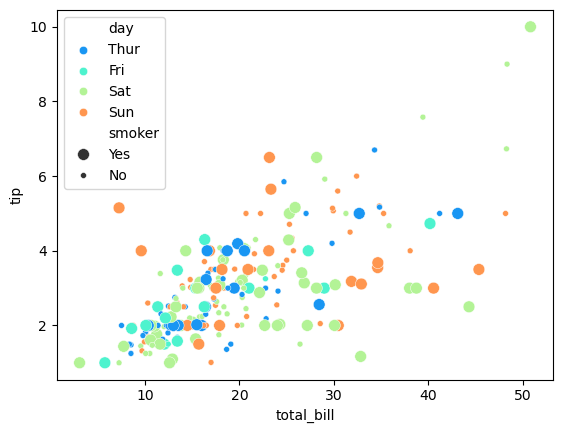

In [10]:
custom_palette = {'Female': 'yellow', 'Male': 'red'}
sns.scatterplot(x=df['total_bill'], y=df['tip'], hue=df['day'],
                size=df['smoker'], palette='rainbow')

In [11]:
df1 = pd.read_csv('./data/global_internet_users.csv')
df1.head(5)

,Unnamed: 0,Entity,Code,Year,Cellular Subscription,Internet Users(%),No. of Internet Users,Broadband Subscription
0,0,Afghanistan,AFG,1980,0.0,0.0,0,0.0
1,1,Afghanistan,AFG,1981,0.0,0.0,0,0.0
2,2,Afghanistan,AFG,1982,0.0,0.0,0,0.0
3,3,Afghanistan,AFG,1983,0.0,0.0,0,0.0
4,4,Afghanistan,AFG,1984,0.0,0.0,0,0.0


<Axes: xlabel='Year', ylabel='No. of Internet Users'>

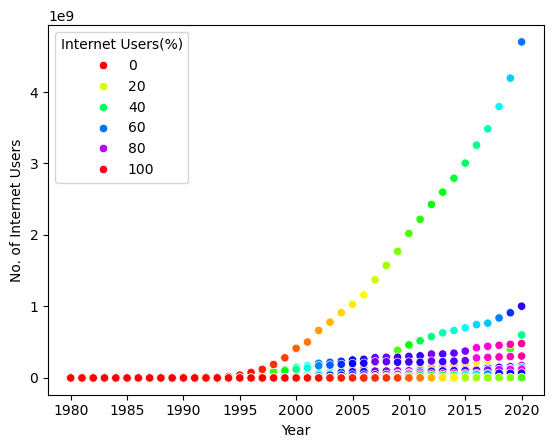

In [12]:
sns.scatterplot(x='Year', y='No. of Internet Users', data=df1, hue='Internet Users(%)', palette='hsv')

In [13]:
# 연도별 사용자 - 국가/지역 별로 구분해서 시각화
df1.Entity.unique()
entites = ['China', 'India', 'Finland']
df_country = df1.loc[df1['Entity'].isin(entites)]
df_country[:5]

,Unnamed: 0,Entity,Code,Year,Cellular Subscription,Internet Users(%),No. of Internet Users,Broadband Subscription
1579,1579,China,CHN,1980,0.0,0.0,0,0.0
1580,1580,China,CHN,1981,0.0,0.0,0,0.0
1581,1581,China,CHN,1982,0.0,0.0,0,0.0
1582,1582,China,CHN,1983,0.0,0.0,0,0.0
1583,1583,China,CHN,1984,0.0,0.0,0,0.0


<Axes: xlabel='Year', ylabel='No. of Internet Users'>

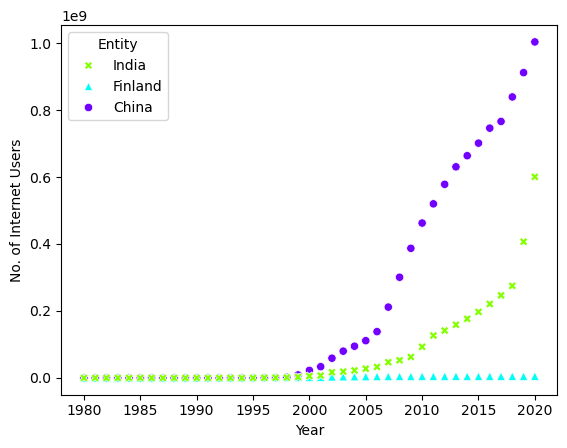

In [14]:
sns.scatterplot(x='Year', y='No. of Internet Users', data=df_country, hue='Entity', 
                hue_order=['India', 'Finland', 'China'] ,palette='hsv', markers=['o', '^', 'X'], style='Entity')

In [17]:
import plotly.express as px
fig = px.scatter(data_frame=df1, x='Year', y='No. of Internet Users', width=400, height=400)
fig.show()

In [24]:
color = px.colors.qualitative.Light24
fig1 = px.scatter(data_frame=df_country, x='Year', y='No. of Internet Users', 
                  width=400, height=400, color='Entity', color_discrete_sequence=color,
                  symbol='Entity',
                  size='No. of Internet Users') # marker와 같은 기능

fig1.show()


- 산점도는 데이터의 양에 따라 효과가 달라진다
- size 그룹간 차이 식별이 어려워질 수 있다
- 최대 2개정도 까지만 구별 - hue, style

# regplot - 산점도에 회귀 표시

<Axes: xlabel='total_bill', ylabel='tip'>

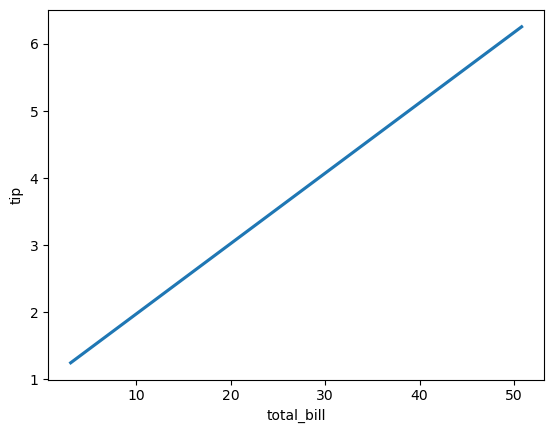

In [28]:
# 선 주변의 색칠된 영역은 오차구간 - ci 속성
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, # scatter 안보이게
            ci =  None) 

<Axes: xlabel='size', ylabel='tip'>

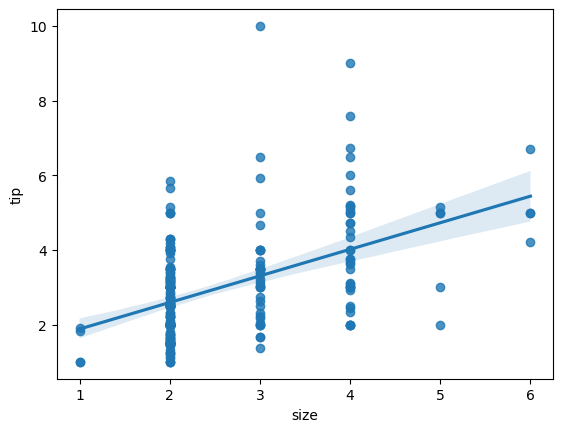

In [30]:
sns.regplot(data=df, x='size', y='tip') 